# BMW M54B25

Bu notebook, AI Mechanic veri setindeki BMW M54B25 ses kayıtlarını FFT ile analiz ederek
frekans tablomuza gerçek ölçüm değerlerini nasıl ekledğimizi göstermektedir.

**Veri Kaynakları:**
- AI Mechanic Dataset (Kaggle): BMW M54B25 ses kayıtları (.wav)
- Frekans Referans Tablosu: BMW, Audi, VW, Mercedes, Ford, Lamborghini motor parametreleri

**Amaç:** M54B25 motorunun gerçek frekans değerlerini ölçerek referans tablomuza eklemek

**Etiketler:**
- `normal engine inside cabin` → Sağlıklı motor
- `air leak engine inside cabin` / `air leak` → Hava kaçağı arızası
- `oil cap off engine inside cabin` → Yağ kapağı açık arızası
- `idling` → Rölanti
- `Background Noise` → Arka plan gürültüsü (eğitimde kullanılmaz)

## 1. Kütüphaneler

In [56]:
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import os
import json
from pathlib import Path

## 2. Mevcut Frekans Referans Tablosu


In [57]:
df_referans = pd.read_excel('tez.xlsx')
df_referans.head()


,Üretici,Motor Kodu,Konfigürasyon,Analiz Modu,Parametre,Birim,Minimum Frekans (Hz),Maksimum Frekans (Hz),Mühendislik Notu
0,BMW Group,B58B30M1,6-Silindir Sıralı Turbo,Stok (Sağlıklı),Ateşleme Frekansı (2. Kademe),Hz,37.5,350.0,Normal yanma frekansı (RPM x 3 / 60)
1,BMW Group,B58B30M1,6-Silindir Sıralı Turbo,Stok (Sağlıklı),Turboşarj (1x Mil Hızı),Hz,333,3000.0,~20.000 - 180.000 RPM arası normal mil sesi
2,BMW Group,B58B30M1,6-Silindir Sıralı Turbo,Arıza Modu,Turbo Mil Dengesizliği,Hz,333,3000.0,Yüksek Genlik! (1x Mil hızında aşırı titreşim)
3,BMW Group,B58B30M1,6-Silindir Sıralı Turbo,Arıza Modu,Turbo Pervane Hasarı (BPF),Hz,3000,27000.0,(BPF = Blade Pass Frequency) Stokta olmayan ha...
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. info.labels Dosyasını Oku ve Dosyaları Grupla

In [58]:
DATASET_PATH = r"datasets\ai-mechanic-export" 

labels_path = Path(DATASET_PATH) / "info.labels"
with open(labels_path, "r") as f:
    labels_data = json.load(f)

normal_files   = []
air_leak_files = []
oil_cap_files  = []
rolanti_files  = []
gurultu_files  = []

for item in labels_data['files']:
    if item['category'] != 'training':
        continue
    etiket = item['label']['label'].lower()
    dosya  = Path(DATASET_PATH) / item['path']
    if 'normal' in etiket:
        normal_files.append(dosya)
    elif 'air leak' in etiket:
        air_leak_files.append(dosya)
    elif 'oil cap' in etiket:
        oil_cap_files.append(dosya)
    elif 'idling' in etiket:
        rolanti_files.append(dosya)
    elif 'background' in etiket:
        gurultu_files.append(dosya)

print(f'Normal motor       : {len(normal_files)} dosya')
print(f'Hava kaçağı        : {len(air_leak_files)} dosya')
print(f'Yağ kapağı açık    : {len(oil_cap_files)} dosya')
print(f'Rölanti            : {len(rolanti_files)} dosya')
print(f'Arka plan gürültü  : {len(gurultu_files)} dosya (eğitimde kullanılmayacak)')

Normal motor       : 4 dosya
Hava kaçağı        : 13 dosya
Yağ kapağı açık    : 4 dosya
Rölanti            : 6 dosya
Arka plan gürültü  : 7 dosya (eğitimde kullanılmayacak)


## 4. FFT Analizi — Gerçek Frekansları Ölç

In [59]:
def fft_analiz(dosya_yolu, top_n=5, min_freq=20, max_freq=3000):
    audio, sr = librosa.load(str(dosya_yolu), sr=22050)
    fft       = np.abs(np.fft.rfft(audio))
    freqs     = np.fft.rfftfreq(len(audio), 1/sr)
    
    # 20 Hz altı ve 3000 Hz üstünü filtrele
    mask      = (freqs >= min_freq) & (freqs <= max_freq)
    fft_f     = fft[mask]
    freqs_f   = freqs[mask]
    
    top_idx   = np.argsort(fft_f)[-top_n:][::-1]
    return freqs, fft, freqs_f[top_idx], fft_f[top_idx]

def grup_analiz(dosya_listesi, etiket):
    sonuclar = []
    for dosya in dosya_listesi:
        _, _, top_freqs, top_amps = fft_analiz(dosya)
        sonuclar.append({
            'dosya'         : Path(dosya).name,
            'etiket'        : etiket,
            'dominant_freq' : top_freqs[0],
            'freq_2'        : top_freqs[1] if len(top_freqs) > 1 else None,
            'max_amplitud'  : top_amps[0]
        })
    return pd.DataFrame(sonuclar)

df_normal   = grup_analiz(normal_files,   'normal')
df_air_leak = grup_analiz(air_leak_files, 'air_leak')
df_oil_cap  = grup_analiz(oil_cap_files,  'oil_cap_off')
df_rolanti  = grup_analiz(rolanti_files,  'idling')

df_fft = pd.concat([df_normal, df_air_leak, df_oil_cap, df_rolanti], ignore_index=True)

print('Etiket bazında dominant frekans istatistikleri:')
print(df_fft.groupby('etiket')['dominant_freq'].describe())

Etiket bazında dominant frekans istatistikleri:
             count         mean          std        min         25%  \
etiket                                                                
air_leak      13.0  1520.987183   982.853764  36.491232  177.831091   
idling         6.0  1334.694760   985.917867  33.001894  508.375000   
normal         4.0   557.000513  1062.011329  21.360721   23.140781   
oil_cap_off    4.0    34.661726     0.189364  34.414495   34.562834   

                     50%          75%          max  
etiket                                              
air_leak     2150.000000  2150.000000  2150.000000  
idling       1710.500000  2150.000000  2150.000000  
normal         28.320666   562.180398  2150.000000  
oil_cap_off    34.711172    34.810064    34.810064  


## 5. FFT Görselleştirme — Normal vs Arızalı

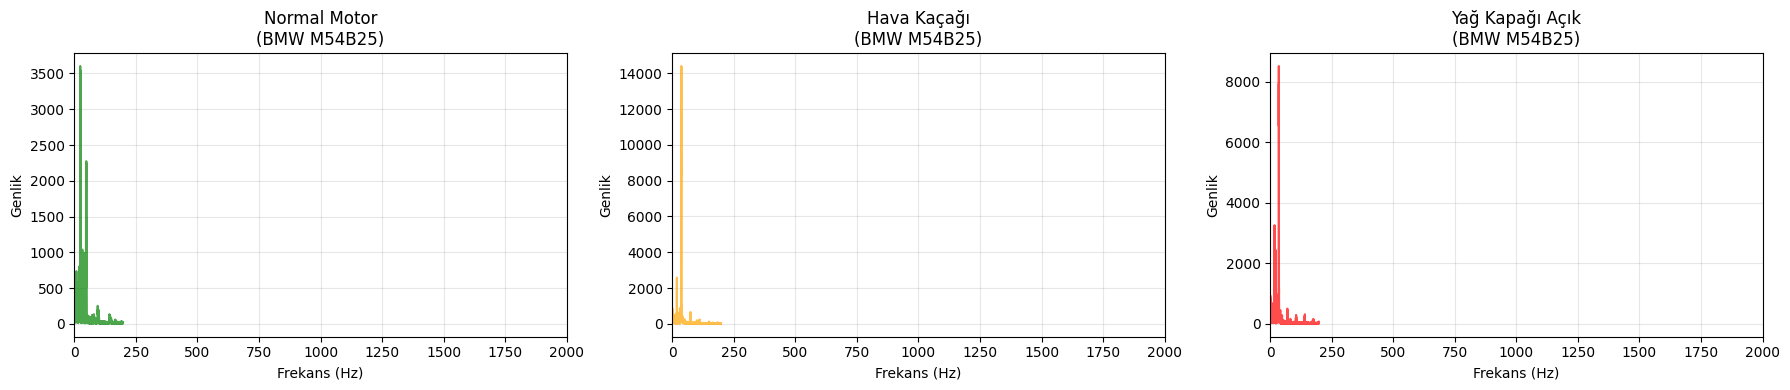

Grafik kaydedildi: fft_karsilastirma.png


In [60]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

dosyalar = [
    (normal_files[0],   'Normal Motor',      'green'),
    (air_leak_files[0], 'Hava Kaçağı',       'orange'),
    (oil_cap_files[0],  'Yağ Kapağı Açık',   'red'),
]

for ax, (dosya, baslik, renk) in zip(axes, dosyalar):
    freqs, fft, _, _ = fft_analiz(dosya)
    ax.plot(freqs[:2000], fft[:2000], color=renk, alpha=0.7)
    ax.set_title(f'{baslik}\n(BMW M54B25)')
    ax.set_xlabel('Frekans (Hz)')
    ax.set_ylabel('Genlik')
    ax.set_xlim(0, 2000)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fft_karsilastirma.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik kaydedildi: fft_karsilastirma.png')

## 6. M54B25 Satırlarını Tabloya Ekle

In [61]:
# Normal için 2150'yi dışarıda bırak
normal_freqs = df_normal['dominant_freq']
normal_freqs = normal_freqs[normal_freqs < 2000]
normal_min   = normal_freqs.min()
normal_max   = normal_freqs.max()

# Air leak için 2150'yi dışarıda bırak
air_freqs = df_air_cabin['dominant_freq']
air_freqs = air_freqs[air_freqs < 2000]
air_min   = air_freqs.min()
air_max   = air_freqs.max()

# Oil cap zaten temiz
oil_min = df_oil_cap['dominant_freq'].min()
oil_max = df_oil_cap['dominant_freq'].max()

print(f'Normal motor    → {normal_min:.1f} - {normal_max:.1f} Hz')
print(f'Hava kaçağı     → {air_min:.1f} - {air_max:.1f} Hz')
print(f'Yağ kapağı açık → {oil_min:.1f} - {oil_max:.1f} Hz')

yeni_satirlar = pd.DataFrame([
    {
        'Üretici'              : 'BMW Group',
        'Motor Kodu'           : 'M54B25',
        'Konfigürasyon'        : '6-Silindir Sıralı Atmosferik',
        'Analiz Modu'          : 'Stok (Sağlıklı)',
        'Parametre'            : 'Ateşleme Frekansı (3. Kademe)',
        'Birim'                : 'Hz',
        'Minimum Frekans (Hz)' : round(normal_min, 1),
        'Maksimum Frekans (Hz)': round(normal_max, 1),
        'Mühendislik Notu'     : 'Normal yanma (RPM x 3 / 60) — FFT ile ölçüldü (AI Mechanic dataset)'
    },
    {
        'Üretici'              : 'BMW Group',
        'Motor Kodu'           : 'M54B25',
        'Konfigürasyon'        : '6-Silindir Sıralı Atmosferik',
        'Analiz Modu'          : 'Arıza Modu',
        'Parametre'            : 'Hava Kaçağı (Air Leak)',
        'Birim'                : 'Hz',
        'Minimum Frekans (Hz)' : round(air_min, 1),
        'Maksimum Frekans (Hz)': round(air_max, 1),
        'Mühendislik Notu'     : 'Hava intake bozukluğu — FFT ile ölçüldü (AI Mechanic dataset)'
    },
    {
        'Üretici'              : 'BMW Group',
        'Motor Kodu'           : 'M54B25',
        'Konfigürasyon'        : '6-Silindir Sıralı Atmosferik',
        'Analiz Modu'          : 'Arıza Modu',
        'Parametre'            : 'Yağ Kapağı Açık (Oil Cap Off)',
        'Birim'                : 'Hz',
        'Minimum Frekans (Hz)' : round(oil_min, 1),
        'Maksimum Frekans (Hz)': round(oil_max, 1),
        'Mühendislik Notu'     : 'Yağ kapağı sökük, basınç kaçağı — FFT ile ölçüldü (AI Mechanic dataset)'
    }
])

df_guncellenmis = pd.concat([df_referans, yeni_satirlar], ignore_index=True)
df_guncellenmis = df_guncellenmis.dropna(how='all').reset_index(drop=True)
print(f'\nGüncellenmiş tablo: {len(df_guncellenmis)} satır')
df_guncellenmis.tail(6)

Normal motor    → 21.4 - 32.9 Hz
Hava kaçağı     → 36.5 - 37.0 Hz
Yağ kapağı açık → 34.4 - 34.8 Hz

Güncellenmiş tablo: 22 satır


,Üretici,Motor Kodu,Konfigürasyon,Analiz Modu,Parametre,Birim,Minimum Frekans (Hz),Maksimum Frekans (Hz),Mühendislik Notu
16,Audi (Lamborghini),5.2 V10 FSI,10-Silindir V-tipi (Atmosferik),Stok (Sağlıklı),Ateşleme Frekansı (5. Kademe),Hz,70.8,725.0,"Normal yanma (RPM x 5 / 60), (Atmosferik)"
17,Audi (Lamborghini),5.2 V10 FSI,10-Silindir V-tipi (Atmosferik),Stok (Sağlıklı),Enjektör Açılma Sesi,Hz,2025-01-14 00:00:00,145.0,Enjektörlerin çalışma sesi (1x RPM hızı)
18,Audi (Lamborghini),5.2 V10 FSI,10-Silindir V-tipi (Atmosferik),Arıza Modu,Piston Vuruntusu (Knock),Hz,5000,15000.0,Çok Yüksek Frekans! (Sensörler tarafından algı...
19,BMW Group,M54B25,6-Silindir Sıralı Atmosferik,Stok (Sağlıklı),Ateşleme Frekansı (3. Kademe),Hz,21.4,32.9,Normal yanma (RPM x 3 / 60) — FFT ile ölçüldü ...
20,BMW Group,M54B25,6-Silindir Sıralı Atmosferik,Arıza Modu,Hava Kaçağı (Air Leak),Hz,36.5,37.0,Hava intake bozukluğu — FFT ile ölçüldü (AI Me...
21,BMW Group,M54B25,6-Silindir Sıralı Atmosferik,Arıza Modu,Yağ Kapağı Açık (Oil Cap Off),Hz,34.4,34.8,"Yağ kapağı sökük, basınç kaçağı — FFT ile ölçü..."


In [62]:
for dosya in normal_files:
    _, _, top_freqs, _ = fft_analiz(dosya)
    print(f'{dosya.name[:40]} → {top_freqs[0]:.1f} Hz')

normal engine inside cabin.2q8n8mk2.inge → 23.7 Hz
normal engine inside cabin.2q8nagl9.inge → 21.4 Hz
normal engine inside cabin.2qsi3v93.inge → 32.9 Hz
normal engine inside cabin.2qsienhj.inge → 2150.0 Hz
